# Credit Card Default Risk: an Interpretable Scorecard

**Portfolio project for credit risk and data analyst roles**

This notebook builds a next-month default-risk model from UCI's historical credit-card portfolio. It uses SQLite for portfolio summaries, training-only WoE/IV screening, a logistic scorecard, an XGBoost benchmark, ranking metrics, and approval-policy trade-offs.

> **Scope:** the source is Taiwanese data from 2005 and represents existing card clients. It is an educational demonstration, not a model for current Australian lending decisions. Demographic fields are profiled only and excluded from model inputs.

## 1. Reproducible setup

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

# Find the project root even if Jupyter starts in the notebooks/ subdirectory.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src" / "credit_risk.py").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src" / "credit_risk.py").exists():
    raise FileNotFoundError("Run this notebook from the project checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_risk import (
    DEMOGRAPHIC_COLUMNS,
    PAYMENT_STATUS_COLUMNS,
    TARGET,
    WoEEncoder,
    approval_policy_table,
    build_scorecard,
    ks_statistic,
    load_uci_dataset,
    score_from_probability,
)

RANDOM_STATE = 42
CORRELATION_LIMIT = 0.65
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
print("Project root found; using the local UCI data cache when available.")
print(f"pandas {pd.__version__} | NumPy {np.__version__}")


Project root found; using the local UCI data cache when available.
pandas 3.0.6 | NumPy 2.5.3


## 2. Load and check the UCI data

In [2]:
data = load_uci_dataset(PROJECT_ROOT / "data" / "raw")
duplicate_profiles_removed = int(data.attrs.get("duplicate_profiles_removed", -1))
assert len(data) == 29_965, f"Unexpected de-duplicated profile count: {len(data):,}"
assert duplicate_profiles_removed == 35, f"Unexpected removed duplicate profiles: {duplicate_profiles_removed}"
assert data.duplicated().sum() == 0
assert TARGET in data and set(data[TARGET].unique()) == {0, 1}
assert not data.isna().any().any(), "Unexpected missing values need review."

print(f"Unique modeling profiles: {len(data):,} | fields including target: {data.shape[1]}")
print(f"Exact repeated feature/outcome rows removed after dropping ID: {duplicate_profiles_removed}")
print(f"Observed next-month default rate: {data[TARGET].mean():.2%}")
display(data.head())
display(
    pd.DataFrame(
        {
            "dtype": data.dtypes.astype(str),
            "missing values": data.isna().sum(),
            "unique values": data.nunique(),
        }
    ).T
)


Unique modeling profiles: 29,965 | fields including target: 24
Exact repeated feature/outcome rows removed after dropping ID: 35
Observed next-month default rate: 22.13%


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_flag
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_flag
dtype,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int8
missing values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
unique values,81,2,4,3,56,11,11,11,11,10,10,22723,22346,22026,21548,21010,20604,7943,7899,7518,6937,6897,6939,2


The source workbook has a descriptive first row and field names on its second row. The loader removes duplicate IDs, drops the ID column, then removes 35 exact duplicate feature/outcome rows so identical records cannot straddle the train and test partitions. This leaves 29,965 unique modeling profiles from 30,000 source rows. It maps education/marriage codes to the documented ‘other’ groups and checks numeric fields, missingness and the binary target. The UCI source reports no missing values; the notebook fails clearly if that assumption changes.

## 3. Exploratory analysis

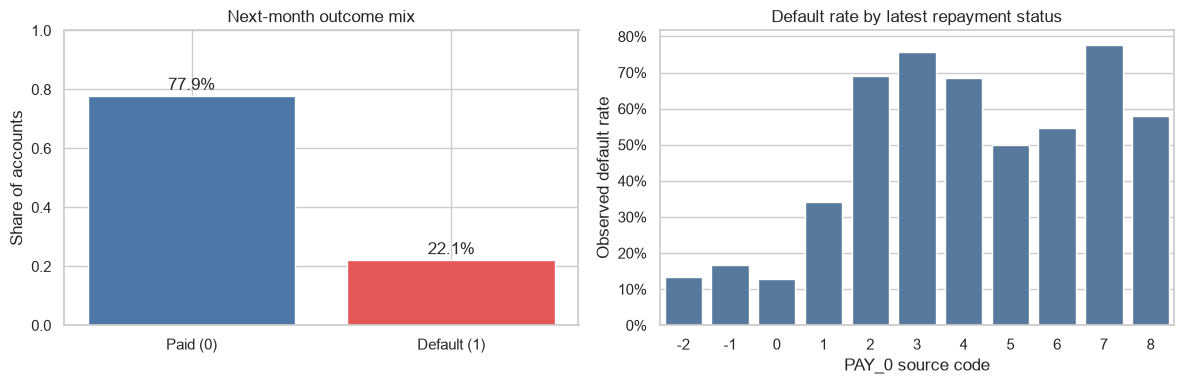

,pay_0,accounts,default_rate_pct
0,-2,2750,13.24
1,-1,5682,16.79
2,0,14737,12.81
3,1,3667,34.03
4,2,2666,69.13
5,3,322,75.78
6,4,76,68.42
7,5,26,50.00
8,6,11,54.55
9,7,9,77.78


Repayment status code note: UCI defines -1 as paid duly and positive codes as months past due.
The UCI variable notes do not define -2 or 0; these observed codes are preserved and grouped only as non-positive delay codes in the scorecard.


,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6
-2,2750,3752,4055,4318,4516,4865
-1,5682,6046,5934,5683,5535,5736
0,14737,15730,15764,16455,16947,16286
1,3667,28,4,2,0,0
2,2666,3926,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,75,68,83,48
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


Undocumented education and marriage codes are folded into the source's 'other' groups:


,education,marriage
1,10563,13643
2,14019,15945
3,4915,377
4,468,0


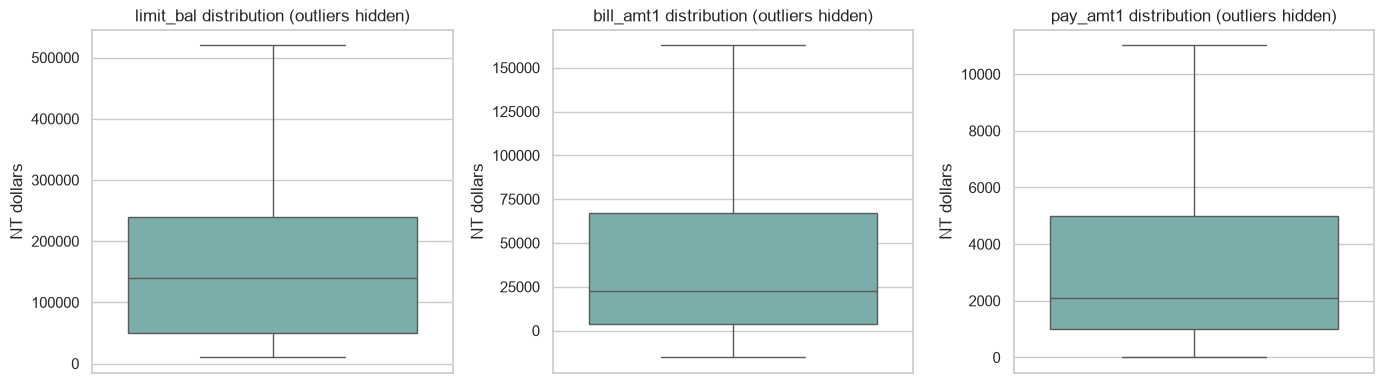

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_share = data[TARGET].value_counts(normalize=True).sort_index()
axes[0].bar(["Paid (0)", "Default (1)"], target_share.values, color=["#4C78A8", "#E45756"])
axes[0].set(title="Next-month outcome mix", ylabel="Share of accounts", ylim=(0, 1))
for i, share in enumerate(target_share.values):
    axes[0].text(i, share + 0.02, f"{share:.1%}", ha="center")

latest_status = (
    data.groupby("pay_0", as_index=False)[TARGET]
    .agg(default_rate="mean", accounts="size")
    .sort_values("pay_0")
)
sns.barplot(data=latest_status, x="pay_0", y="default_rate", color="#4C78A8", ax=axes[1])
axes[1].set(title="Default rate by latest repayment status", xlabel="PAY_0 source code", ylabel="Observed default rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()

display(latest_status.assign(default_rate_pct=latest_status.pop("default_rate") * 100).round(2))
print("Repayment status code note: UCI defines -1 as paid duly and positive codes as months past due.")
print("The UCI variable notes do not define -2 or 0; these observed codes are preserved and grouped only as non-positive delay codes in the scorecard.")
display(data[PAYMENT_STATUS_COLUMNS].apply(lambda column: column.value_counts().sort_index()).fillna(0).astype(int))
print("Undocumented education and marriage codes are folded into the source's 'other' groups:")
display(pd.DataFrame({
    "education": data["education"].value_counts().sort_index(),
    "marriage": data["marriage"].value_counts().sort_index(),
}).fillna(0).astype(int))

plot_fields = ["limit_bal", "bill_amt1", "pay_amt1"]
fig, axes = plt.subplots(1, len(plot_fields), figsize=(14, 4))
for axis, feature in zip(axes, plot_fields, strict=True):
    sns.boxplot(y=data[feature], showfliers=False, color="#72B7B2", ax=axis)
    axis.set(title=f"{feature} distribution (outliers hidden)", ylabel="NT dollars")
plt.tight_layout()
plt.show()


## 4. Portfolio summaries in SQLite

Load the cleaned frame into an in-memory SQLite table and run the reusable queries in `sql/eda_queries.sql`.

In [4]:
connection = sqlite3.connect(":memory:")
data.to_sql("credit_clients", connection, if_exists="replace", index=False)
query_text = (PROJECT_ROOT / "sql" / "eda_queries.sql").read_text(encoding="utf-8")
sql_queries = [query.strip() for query in query_text.split(";") if query.strip()]
assert len(sql_queries) == 3

for query_number, query in enumerate(sql_queries, start=1):
    print(f"SQL summary {query_number}")
    display(pd.read_sql_query(query, connection))
connection.close()

SQL summary 1


,accounts,defaults,default_rate_pct
0,29965,6630,22.13


SQL summary 2


,latest_payment_status,accounts,defaults,default_rate_pct
0,-2,2750,364,13.24
1,-1,5682,954,16.79
2,0,14737,1888,12.81
3,1,3667,1248,34.03
4,2,2666,1843,69.13
5,3,322,244,75.78
6,4,76,52,68.42
7,5,26,13,50.00
8,6,11,6,54.55
9,7,9,7,77.78


SQL summary 3


,credit_limit_band,accounts,defaults,default_rate_pct
0,< 50k,4310,1554,36.06
1,50k-149k,10970,2767,25.22
2,150k-299k,9577,1612,16.83
3,300k+,5108,697,13.65


## 5. Split the data and define model inputs

Use a stratified 60%/20%/20% train/validation/test split with a fixed seed. The model deliberately excludes sex, education, marital status and age. Credit limit and repayment/billing history remain as candidate account-behaviour inputs. Split before fitting any binning or feature screen to keep the holdout untouched.

In [5]:
excluded_columns = [TARGET, *DEMOGRAPHIC_COLUMNS]
model_features = [column for column in data.columns if column not in excluded_columns]
X = data[model_features].copy()
y = data[TARGET].copy()

X_train_validation, X_test, y_train_validation, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_validation,
    y_train_validation,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_validation,
)

split_summary = pd.DataFrame(
    {
        "partition": ["train", "validation", "test"],
        "accounts": [len(y_train), len(y_validation), len(y_test)],
        "default rate": [y_train.mean(), y_validation.mean(), y_test.mean()],
    }
)
display(split_summary.style.format({"default rate": "{:.2%}"}))
print(f"Model inputs ({len(model_features)}): {model_features}")
print(f"Demographic fields excluded: {DEMOGRAPHIC_COLUMNS}")

,partition,accounts,default rate
0,train,17979,22.13%
1,validation,5993,22.13%
2,test,5993,22.13%


Model inputs (19): ['limit_bal', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']
Demographic fields excluded: ['sex', 'education', 'marriage', 'age']


## 6. Training-only WoE/IV feature screening

Continuous fields start with training-set quantile bins. Adjacent bins are pooled with a pool-adjacent-violators procedure so training default rates are monotonic; payment histories are grouped into no-positive-delay codes, one month past due, and two or more months past due, with rare or non-monotonic adjacent groups merged. Smoothed WoE is `ln(good share / bad share)`, where good is non-default. All cut points, merges, WoE values and IVs are fit on training data only. The `IV > 0.02` rule is a univariate screen; a second training-only Spearman filter removes a lower-IV candidate when its WoE-transformed feature is correlated at 0.65 or above with a higher-IV retained feature. Both are screening heuristics, not evidence of causal or stable value.

In [6]:
categorical_features = [column for column in PAYMENT_STATUS_COLUMNS if column in X_train.columns]
encoder = WoEEncoder(
    categorical_columns=categorical_features,
    max_bins=5,
    min_category_count=30,
    smoothing=0.5,
).fit(X_train, y_train)

iv_results = encoder.iv_table_.copy()
iv_results["selected_by_iv"] = iv_results["iv"] > 0.02
iv_candidates = iv_results.loc[iv_results["selected_by_iv"], "feature"].tolist()
if not iv_candidates:
    raise ValueError("No features passed the training-only IV > 0.02 screen.")

X_train_woe_all = encoder.transform(X_train)[iv_candidates]
woe_correlation = X_train_woe_all.corr(method="spearman").abs()
selected_features = []
selection_rows = []
for feature in iv_candidates:  # iv_results is sorted from highest to lowest training IV.
    if selected_features:
        prior_correlations = woe_correlation.loc[feature, selected_features]
        max_corr_feature = prior_correlations.idxmax()
        max_corr = float(prior_correlations.max())
    else:
        max_corr_feature, max_corr = "", 0.0
    keep = max_corr < CORRELATION_LIMIT
    iv_value = float(iv_results.loc[iv_results["feature"].eq(feature), "iv"].iloc[0])
    selection_rows.append({
        "feature": feature,
        "iv": iv_value,
        "max_abs_spearman_to_higher_iv": max_corr,
        "compared_with": max_corr_feature,
        "selected_after_correlation": keep,
    })
    if keep:
        selected_features.append(feature)
if not selected_features:
    raise ValueError("No features remained after the training-only correlation screen.")

correlation_screen = pd.DataFrame(selection_rows)
iv_results = iv_results.merge(correlation_screen, on=["feature", "iv"], how="left")
iv_results["selected"] = iv_results["selected_after_correlation"].fillna(False)
display(iv_results.style.format({
    "iv": "{:.4f}",
    "train_missing_pct": "{:.2%}",
    "max_abs_spearman_to_higher_iv": "{:.3f}",
}))
print(f"Selected {len(selected_features)} of {len(model_features)} behavior features after IV and correlation screens.")
retained_correlation = woe_correlation.loc[selected_features, selected_features].copy()
retained_correlation = retained_correlation.mask(np.eye(len(selected_features), dtype=bool))
print(f"Maximum absolute Spearman correlation among retained WoE features: {retained_correlation.max().max():.3f}")
display(encoder.bin_table_.loc[encoder.bin_table_["feature"].isin(selected_features)].reset_index(drop=True))

X_train_woe = X_train_woe_all[selected_features]
X_validation_woe = encoder.transform(X_validation)[selected_features]


,feature,iv,bins,train_missing_pct,selected_by_iv,max_abs_spearman_to_higher_iv,compared_with,selected_after_correlation,selected
0,pay_0,0.8817,3,0.00%,True,0.000,,True,True
1,pay_2,0.5489,2,0.00%,True,0.676,pay_0,False,False
2,pay_3,0.4067,2,0.00%,True,0.447,pay_0,True,True
3,pay_4,0.3476,2,0.00%,True,0.624,pay_3,True,True
4,pay_5,0.3199,2,0.00%,True,0.665,pay_4,False,False
5,pay_6,0.2596,2,0.00%,True,0.497,pay_4,True,True
6,pay_amt1,0.1623,5,0.00%,True,0.283,pay_0,True,True
7,limit_bal,0.1595,5,0.00%,True,0.258,pay_amt1,True,True
8,pay_amt2,0.1408,5,0.00%,True,0.493,pay_amt1,True,True
9,pay_amt3,0.1310,5,0.00%,True,0.506,pay_amt2,True,True


Selected 11 of 19 behavior features after IV and correlation screens.
Maximum absolute Spearman correlation among retained WoE features: 0.624


,feature,bin,training_accounts,training_bad_rate,woe,iv_contribution,monotonic_direction
0,limit_bal,0,4626,0.321012,-0.508951,0.075761,decreasing default rate
1,limit_bal,1,2902,0.255686,-0.189828,0.006122,decreasing default rate
2,limit_bal,2,3637,0.196041,0.152797,0.004522,decreasing default rate
3,limit_bal,3,3266,0.166565,0.351538,0.020257,decreasing default rate
4,limit_bal,4,3548,0.139233,0.562924,0.052855,decreasing default rate
5,pay_0,0,13876,0.137215,0.580313,0.218458,increasing default rate by delay severity
6,pay_0,1,2188,0.337751,-0.585080,0.048158,increasing default rate by delay severity
7,pay_0,2,1915,0.697128,-2.091251,0.615116,increasing default rate by delay severity
8,pay_3,0,15424,0.171810,0.314533,0.077442,increasing default rate by delay severity
9,pay_3,1,2555,0.519765,-1.337241,0.329244,increasing default rate by delay severity


## 7. Fit the logistic scorecard and XGBoost benchmark

The primary model is regularised logistic regression on selected WoE features. XGBoost receives the same candidate behaviour fields, with repayment-status categories one-hot encoded and numeric amounts passed through. Both models are fit only on the training partition; validation is used to compare ranking and set an illustrative policy threshold.

In [7]:
scorecard_model = LogisticRegression(C=1.0, max_iter=2_000, solver="lbfgs", random_state=RANDOM_STATE)
scorecard_model.fit(X_train_woe, y_train)

xgb_categorical = categorical_features
xgb_numeric = [column for column in model_features if column not in xgb_categorical]
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("payment_status", OneHotEncoder(handle_unknown="ignore"), xgb_categorical),
        ("numeric", "passthrough", xgb_numeric),
    ],
    remainder="drop",
)
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", xgb_preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=2.0,
                eval_metric="logloss",
                tree_method="hist",
                n_jobs=4,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
xgb_pipeline.fit(X_train, y_train)

coefficient_audit = pd.DataFrame({
    "feature": selected_features,
    "training IV": [float(encoder.iv_table_.set_index("feature").loc[f, "iv"]) for f in selected_features],
    "logistic coefficient": scorecard_model.coef_[0],
})
display(coefficient_audit.style.format({"training IV": "{:.4f}", "logistic coefficient": "{:.4f}"}))

validation_probabilities = {
    "Logistic scorecard": scorecard_model.predict_proba(X_validation_woe)[:, 1],
    "XGBoost": xgb_pipeline.predict_proba(X_validation)[:, 1],
}
validation_metrics = pd.DataFrame(
    [
        {
            "model": model_name,
            "validation ROC AUC": roc_auc_score(y_validation, probability),
            "validation KS": ks_statistic(y_validation, probability),
        }
        for model_name, probability in validation_probabilities.items()
    ]
)
display(validation_metrics.style.format({"validation ROC AUC": "{:.4f}", "validation KS": "{:.4f}"}))


,feature,training IV,logistic coefficient
0,pay_0,0.8817,-0.7754
1,pay_3,0.4067,-0.2400
2,pay_4,0.3476,-0.1640
3,pay_6,0.2596,-0.3066
4,pay_amt1,0.1623,-0.2732
5,limit_bal,0.1595,-0.2966
6,pay_amt2,0.1408,-0.1496
7,pay_amt3,0.1310,-0.2208
8,pay_amt4,0.0929,-0.3337
9,pay_amt6,0.0861,-0.0789


,model,validation ROC AUC,validation KS
0,Logistic scorecard,0.7681,0.4133
1,XGBoost,0.7852,0.4382


## 8. Select an illustrative approval threshold on validation

To make the business trade-off concrete, assume an illustrative policy appetite of no more than 10% observed default among approved validation accounts. Search a fixed PD grid and choose the highest cut-off meeting that constraint. If no tested threshold meets it, select the lowest observed validation bad-rate point and flag that the target was not met. This is a worked example only; the appetite is not a recommendation.

In [8]:
validation_pd = validation_probabilities["Logistic scorecard"]
threshold_grid = np.linspace(0.005, min(0.60, float(validation_pd.max())), 120)
validation_policy = approval_policy_table(y_validation, validation_pd, threshold_grid)
feasible_policy = validation_policy.loc[
    validation_policy["bad rate among approved"].le(0.10)
    & validation_policy["approval rate"].gt(0)
]

if len(feasible_policy):
    chosen_policy = feasible_policy.sort_values("PD approval threshold").iloc[-1]
    validation_policy_target_met = True
else:
    nonempty_policy = validation_policy.loc[validation_policy["approval rate"].gt(0)]
    chosen_policy = nonempty_policy.sort_values(
        ["bad rate among approved", "PD approval threshold"], ascending=[True, True]
    ).iloc[0]
    validation_policy_target_met = False
chosen_threshold = float(chosen_policy["PD approval threshold"])
print(f"Chosen PD cut-off: {chosen_threshold:.3f}")
print(f"Validation observed bad rate at cut-off: {chosen_policy['bad rate among approved']:.2%}")
print(f"10% validation appetite met: {validation_policy_target_met}")
display(
    approval_policy_table(
        y_validation,
        validation_pd,
        [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    ).style.format({
        "PD approval threshold": "{:.2f}",
        "approval rate": "{:.1%}",
        "bad rate among approved": "{:.1%}",
        "share of all defaults approved": "{:.1%}",
    })
)

Chosen PD cut-off: 0.150
Validation observed bad rate at cut-off: 9.75%
10% validation appetite met: True


,PD approval threshold,approval rate,bad rate among approved,share of all defaults approved,approved accounts
0,0.05,0.0%,nan%,0.0%,0
1,0.10,21.6%,7.2%,7.0%,1293
2,0.15,52.3%,9.8%,23.1%,3137
3,0.20,71.6%,12.2%,39.6%,4288
4,0.25,76.8%,13.3%,46.1%,4603
5,0.30,79.5%,13.9%,50.0%,4765
6,0.35,82.6%,14.5%,53.9%,4948
7,0.40,86.2%,15.4%,60.0%,5163
8,0.45,87.8%,16.1%,64.0%,5259
9,0.50,89.1%,16.6%,66.7%,5339


## 9. Final holdout evaluation

Evaluate once on the untouched 20% test set. ROC AUC measures ranking across cut-offs; KS is the maximum separation between the cumulative good and bad distributions. Confusion matrices use a 0.50 PD cut-off for direct model comparison. The separately selected approval cut-off is reported as an operating-point example.

,model,test ROC AUC,test KS
0,Logistic scorecard,0.7541,0.3972
1,XGBoost,0.7702,0.4175


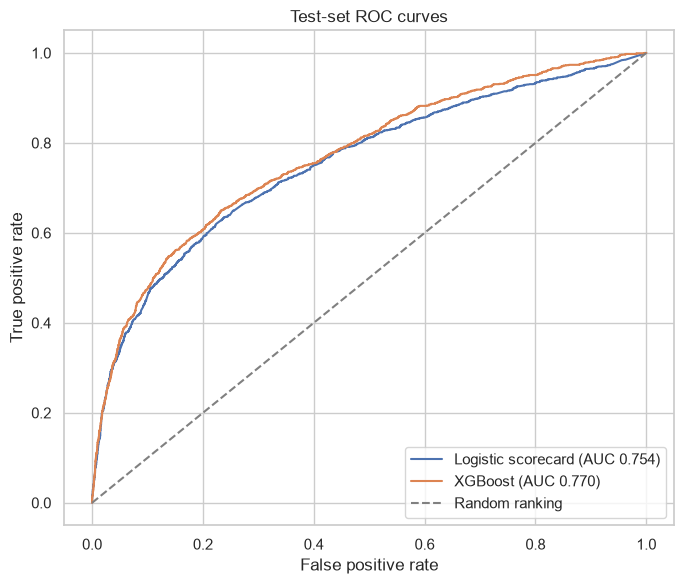

,true negatives,false positives,false negatives,true positives
model,,,,
Logistic scorecard,4433,234,875,451
XGBoost,4437,230,850,476


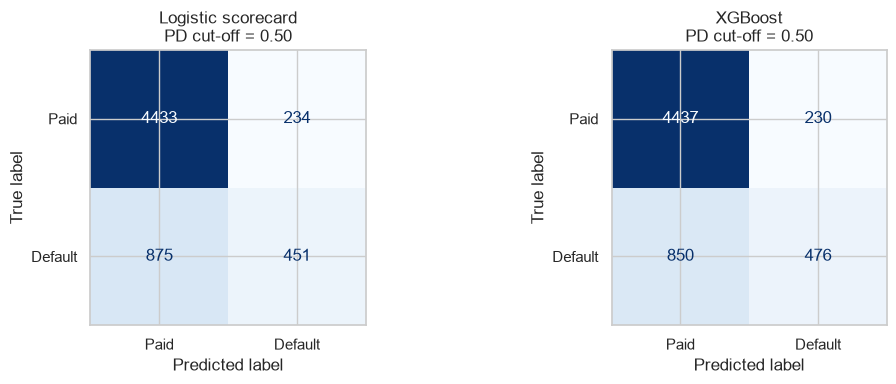

Validation-selected logistic policy evaluated on test:


,PD approval threshold,approval rate,bad rate among approved,share of all defaults approved,approved accounts
0,0.150,52.0%,10.6%,24.9%,3115


,PD approval threshold,approval rate,bad rate among approved,share of all defaults approved,approved accounts
0,0.10,21.1%,8.8%,8.4%,"1,265"
1,0.15,52.0%,10.6%,24.9%,"3,115"
2,0.20,71.9%,12.8%,41.7%,"4,306"
3,0.25,77.2%,13.7%,47.7%,"4,625"
4,0.30,79.5%,14.0%,50.4%,"4,765"
5,0.35,83.0%,15.0%,56.1%,"4,976"
6,0.40,86.0%,15.7%,61.0%,"5,156"
7,0.45,87.5%,16.1%,63.7%,"5,245"
8,0.50,88.6%,16.5%,66.0%,"5,308"


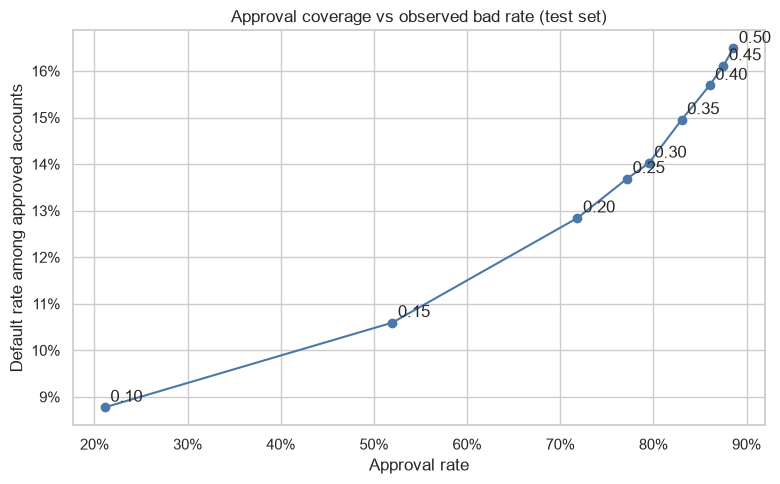

In [9]:
X_test_woe = encoder.transform(X_test)[selected_features]
test_probabilities = {
    "Logistic scorecard": scorecard_model.predict_proba(X_test_woe)[:, 1],
    "XGBoost": xgb_pipeline.predict_proba(X_test)[:, 1],
}
test_metrics = pd.DataFrame(
    [
        {
            "model": model_name,
            "test ROC AUC": roc_auc_score(y_test, probability),
            "test KS": ks_statistic(y_test, probability),
        }
        for model_name, probability in test_probabilities.items()
    ]
)
display(test_metrics.style.format({"test ROC AUC": "{:.4f}", "test KS": "{:.4f}"}))

fig, ax = plt.subplots(figsize=(7, 6))
for model_name, probability in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc = roc_auc_score(y_test, probability)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random ranking")
ax.set(title="Test-set ROC curves", xlabel="False positive rate", ylabel="True positive rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

confusion_rows = []
for model_name, probability in test_probabilities.items():
    tn, fp, fn, tp = confusion_matrix(y_test, probability >= 0.50, labels=[0, 1]).ravel()
    confusion_rows.append({
        "model": model_name,
        "true negatives": tn,
        "false positives": fp,
        "false negatives": fn,
        "true positives": tp,
    })
display(pd.DataFrame(confusion_rows).set_index("model"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for axis, (model_name, probability) in zip(axes, test_probabilities.items(), strict=True):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        (probability >= 0.50).astype(int),
        labels=[0, 1],
        display_labels=["Paid", "Default"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(f"{model_name}\nPD cut-off = 0.50")
plt.tight_layout()
plt.show()

logistic_test_policy = approval_policy_table(
    y_test, test_probabilities["Logistic scorecard"], [chosen_threshold]
)
print("Validation-selected logistic policy evaluated on test:")
display(logistic_test_policy.style.format({
    "PD approval threshold": "{:.3f}",
    "approval rate": "{:.1%}",
    "bad rate among approved": "{:.1%}",
    "share of all defaults approved": "{:.1%}",
}))

threshold_sensitivity = approval_policy_table(
    y_test,
    test_probabilities["Logistic scorecard"],
    [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
)
display(threshold_sensitivity.style.format({
    "PD approval threshold": "{:.2f}",
    "approval rate": "{:.1%}",
    "bad rate among approved": "{:.1%}",
    "share of all defaults approved": "{:.1%}",
    "approved accounts": "{:,.0f}",
}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    threshold_sensitivity["approval rate"],
    threshold_sensitivity["bad rate among approved"],
    marker="o",
    color="#4C78A8",
)
for row in threshold_sensitivity.itertuples(index=False):
    ax.annotate(f"{row[0]:.2f}", (row[1], row[2]), xytext=(4, 4), textcoords="offset points")
ax.set(
    title="Approval coverage vs observed bad rate (test set)",
    xlabel="Approval rate",
    ylabel="Default rate among approved accounts",
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()

## 10. Convert logistic regression into a points scorecard

The point scale uses a base score of 500 at the training portfolio's good-to-bad odds, with 20 points to double those odds. Higher points mean lower predicted default risk. The score is a linear transformation of the fitted logistic log-odds, not a separately calibrated probability. Each bin lists its training population and observed default rate; monotonic bins make the scorecard easier to inspect.

In [10]:
train_good_odds = float((y_train == 0).sum() / (y_train == 1).sum())
base_score = 500
points_to_double_odds = 20
scorecard = build_scorecard(
    scorecard_model,
    encoder,
    selected_features,
    base_score=base_score,
    base_good_odds=train_good_odds,
    points_to_double_odds=points_to_double_odds,
)
display(scorecard.style.format({
    "woe": "{:.4f}",
    "coefficient": "{:.4f}",
    "points": "{:.2f}",
    "training_accounts": "{:,.0f}",
    "training_bad_rate": "{:.1%}",
    "iv_contribution": "{:.4f}",
}, na_rep=""))

for feature in selected_features:
    feature_rows = scorecard.loc[scorecard["feature"].eq(feature)].sort_values("training_bad_rate")
    assert feature_rows["points"].is_monotonic_decreasing, f"Non-monotonic points for {feature}"
assert (scorecard_model.coef_[0] < 0).all(), "Expected good-oriented WoE coefficients to be negative."

test_score = score_from_probability(
    test_probabilities["Logistic scorecard"],
    base_score=base_score,
    base_good_odds=train_good_odds,
    points_to_double_odds=points_to_double_odds,
)
factor = points_to_double_odds / np.log(2)
base_points = base_score - factor * (float(scorecard_model.intercept_[0]) + np.log(train_good_odds))
feature_points = X_test_woe.to_numpy() @ (-factor * scorecard_model.coef_[0])
assert np.allclose(test_score, base_points + feature_points, atol=1e-8)
print(f"Training good-to-bad odds reference: {train_good_odds:.3f}:1")
print(f"Test score range: {test_score.min():.0f} to {test_score.max():.0f}; score 500 is the training portfolio reference point.")
print(f"Spearman correlation (score vs PD): {pd.Series(test_score).corr(pd.Series(test_probabilities['Logistic scorecard']), method='spearman'):.3f}")


,feature,bin,woe,coefficient,points,training_accounts,training_bad_rate,iv_contribution
0,BASE,Intercept and base good:bad odds,,,499.86,,,
1,pay_0,Codes -2/-1/0 (no positive delay code),0.5803,-0.7754,12.98,"13,876",13.7%,0.2185
2,pay_0,Code 1 (one month past due),-0.5851,-0.7754,-13.09,"2,188",33.8%,0.0482
3,pay_0,Codes 2+ (two or more months past due),-2.0913,-0.7754,-46.79,"1,915",69.7%,0.6151
4,pay_3,Codes -2/-1/0 (no positive delay code) + Code 1 (one month past due),0.3145,-0.2400,2.18,"15,424",17.2%,0.0774
5,pay_3,Codes 2+ (two or more months past due),-1.3372,-0.2400,-9.26,"2,555",52.0%,0.3292
6,pay_4,Codes -2/-1/0 (no positive delay code) + Code 1 (one month past due),0.2586,-0.1640,1.22,"15,863",18.0%,0.0548
7,pay_4,Codes 2+ (two or more months past due),-1.3830,-0.1640,-6.54,"2,116",53.1%,0.2928
8,pay_6,Codes -2/-1/0 (no positive delay code) + Code 1 (one month past due),0.2026,-0.3066,1.79,"16,153",18.8%,0.0348
9,pay_6,Codes 2+ (two or more months past due),-1.3085,-0.3066,-11.58,"1,826",51.3%,0.2248


Training good-to-bad odds reference: 3.520:1
Test score range: 407 to 541; score 500 is the training portfolio reference point.
Spearman correlation (score vs PD): -1.000


## 11. Business interpretation and limitations

- A stricter PD cut-off generally approves fewer accounts and lowers the observed default rate among approved accounts; the table makes both effects visible and also reports the share of all defaults that would still be approved.
- The validation-selected cut-off is only an example under a stated 10% validation bad-rate constraint. Test-set outcomes can differ, as the holdout result shows.
- Logistic regression gives an additive, auditable scorecard. XGBoost is a nonlinear benchmark; any lift should be weighed against explainability, stability and operational requirements.
- The sample is historical and geographically different from Australia, reflects existing card clients, and uses a random rather than out-of-time split. It cannot establish current Australian performance, affordability, fairness or compliance.
- A real lender should validate on representative Australian application and repayment data, test future periods and relevant subgroups, calibrate PDs, define loss/cost and affordability policy, and monitor drift and outcomes. Protected or sensitive attributes require appropriate governance even when omitted from the model.

**Conclusion:** this notebook demonstrates a reproducible credit-risk workflow and a transparent risk/coverage discussion. It is a portfolio analysis, not an approval recommendation.